Block 1 - Configuration

Here, there are all physical parameters, material properties and numerical settings.

In [256]:
import numpy as np
import sys
import matplotlib.pyplot as plt
import yaml
from matplotlib.gridspec import GridSpec
from dataclasses import dataclass
from math import erf

sys.path.insert(0, ".")
@dataclass (frozen=True)
class Material:
    name: str
    rho: float
    cp: float
    k: float
    T_melt: float
    T_boil: float
    L_fusion: float
    dT_mushy: float
    eta: float
    eta_2D: float

mat = Material(**yaml.safe_load(open("config/tungsten.yaml")))


# Material properties 
rho = mat.rho #density [kg/m3]
cp = mat.cp #specific heat [J/(kg.K)]
k = mat.k #thermal conductivity [W/(m.K)]
T_melt = mat.T_melt #melting temperature [K]
T_boil = mat.T_boil #boiling temperature [K]
L_fusion = mat.L_fusion #latent heat of fusion [J/kg]
dT_mushy = mat.dT_mushy #mushy zone half-width [K]
alpha = k / (rho * cp) #thermal diffusivity [m2/s]
eta = mat.eta #absorptivity 
eta_2D = mat.eta_2D #calibrated 2D absorptivity (accounts for missing z-diffusion)

# Laser parameters 
T_init = 423.0 #pre-heat temperature [K]
P = 300 #laser power [W]
v_s = 0.4 #scan speed [m/s]
r_b = 23.5e-6 #beam radius [m]
h_lay = 30e-6 #layer thickness [m]
r_0 = r_b
w = r_b


# Numerical domain
Lx = 900e-6 #domain length x [m]
Ly = 500e-6 #domain length y [m]
dx = 5e-6 #grid spacing [m]
dy = 5e-6

Nx = int(Lx / dx)
Ny = int(Ly / dy)

dt_max = dx**2 /(4.0 * alpha) #stability limit
dt = 0.35 * dt_max #35% of dt_max as safety factor
N_steps = int((Lx * 0.80) / (v_s *dt))
x_c0 = 2.0 * r_b #laser start position

#validation checks 
Pe = v_s * r_b / (2 * alpha) #peclet number


print("Block 1: configuration")
print(f"Thermal diffusivity = {alpha:.3e} m2/s")
print(f"Peclet number = {Pe:.3f} (<<1 -> conduction-dominated)")
print()
print(f"Grid: {Nx} x {Ny} cells, dx = {dx*1e6:.0f} microns")
print(f"dt_max = {dt_max:.2e} s -> dt = {dt:.2e} s")
print(f"N_steps = {N_steps}, total scan time = {N_steps*dt*1e3:.2f} ms")
print()

#sanity checks


assert Pe < 1.0, \
    f"WARNING: Pe = {Pe:.2f} > 1 (advection-dominated). "
assert dt < dt_max,\
    f"ERROR: dt > dt_max. CFL violated."

print("All checks passed.")

Block 1: configuration
Thermal diffusivity = 6.745e-05 m2/s
Peclet number = 0.070 (<<1 -> conduction-dominated)

Grid: 179 x 100 cells, dx = 5 microns
dt_max = 9.27e-08 s -> dt = 3.24e-08 s
N_steps = 55505, total scan time = 1.80 ms

All checks passed.


Block 2 - Numerical helpers

Defines and tests all functions used in the time loop:
1. cp_effective: apparent heat capacity (latent heat) 
2. gaussian_source: laser beam
3. laplacian_2D
4. neumann_bc = zero-flux boundary conditions

Each funtion is tested with a simple sanity check before use

In [258]:
# Function definitions

def cp_effective(T):
    """
    Apparent specific heat including latent heat of fusion.
    In the mushy zone, cp is increased to absorb/release latent heat gradually.
    Args: T (ndarray) = temperature field [K]
    Returns: cp_app (ndarray) = apparent specific heat [J/(kg * K)]
    """
    cp_app = np.full_like(T, cp, dtype=float)
    mushy = (T >= T_melt - dT_mushy) & (T <= T_melt + dT_mushy)
    cp_app[mushy] += L_fusion / (2.0 * dT_mushy)
    return cp_app

def gaussian_source(X, Y, xc, yc):
    """
    Surface heat flux from a Gaussian laser beam
    Q = (2 * eta_2D * P) / (pi * r_b^2) * exp (-2 * r^2 / r_b^2)
    Args: X, Y (ndarray): coordinate meshgrids; xc, yc (float): position of laser center [m]
    Returns : Q (ndarray): heat flux [W/m2]
    """
    r2 = (X-xc)**2 + (Y-yc)**2
    return (2 * eta_2D * P / (np.pi * r_b**2)) * np.exp(-2 * r2 / r_b**2)

def ring_source(X, Y, xc, yc, P, r_0, w):
    r = np.sqrt((X-xc)**2 + (Y-yc)**2)
    I1 = (w**2/4.0) * np.exp(-2.0 * r_0**2 / w**2)
    I2 = r_0 * (w/2.0) * np.sqrt(np.pi/2.0) * (1.0 + erf(np.sqrt(2.0) * r_0/w))
    A = eta_2D * P / (2.0 * np.pi * (I1+I2))
    return A * np.exp(-2.0 * (r - r_0)**2 / w**2)

def laplacian_2d(T):
    """
    Args: T (ndarray): temperature field, shape (Ny, Nx) [K]
    Returns: lap (ndarray): Laplacian
    """
    lap = np.zeros_like(T)
    lap[1:-1,1:-1] = (
        (T[1:-1, 2:] -2*T[1:-1,1:-1] +T[1:-1, :-2]) / dx**2
        + (T[2:, 1:-1] -2*T[1:-1, 1:-1] +T[:-2, 1:-1]) / dy**2
    )
    return lap

def neumann_bc(T):
    """
    Zero-flux Neumann boundary conditions on all four edges.
    Args: T(ndarray): temperature field [K]
    Returns: T(ndarray): field with updated boundary cells 
    """
    T[:,0] = T[:,1] #left edge
    T[:, -1] = T[:, -2] #right edge
    T[0, :] = T[1, :] #bottom edge
    T[-1, :] = T[-2, :] #top edge
    return T

#unit tests

print("Block 2: testing helper functions \n")

#test 1
T_cold = np.array([300.0, T_init, T_melt - dT_mushy - 1])
cp_out = cp_effective(T_cold)
assert np.allclose(cp_out, cp), \
    f"FAIL: cp_eff outside mushy zone should equal cp={cp}"
print(f" [OK] cp_effective: correct outside mushy zone")

#test 2
T_mushy = np.array([T_melt])
cp_in = cp_effective(T_mushy)
cp_expected = cp + L_fusion / (2 * dT_mushy)
assert np.isclose(cp_in[0], cp_expected, rtol=1e-6), \
    f"FAIL: cp_eff inside mushy zone. Got {cp_in[0]:.1f}, expected {cp_expected:.1f}"
print(f" [OK] cp_effective: correct inside mushy zone "
      f"(cp_eff = {cp_in[0]:.0f} J/(kg.K))")

#test 3 
x = np.linspace(dx, Lx-dx, Nx)
y = np.linspace(dy, Ly-dy, Ny)
X, Y = np.meshgrid(x, y)
xc, yc = Lx/2, Ly/2
Q = ring_source(X, Y, xc, yc, P, r_0, w)
I1 = (w**2/4.0) * np.exp(-2.0 * r_0**2 / w**2)
I2 = r_0 * (w/2.0) * np.sqrt(np.pi/2.0) * (1.0 + erf(np.sqrt(2.0)) * r_0/w)
Q_peak_expected = eta_2D * P / (2.0 * np.pi * (I1+I2))
assert np.isclose(Q.max(), Q_peak_expected, rtol=0.05), \
    f"FAIL: Q_peak = {Q.max():.3e}, expected {Q_peak_expected:.3e}"
print(f" [OK] ring_source: peak = {Q.max():.3e} W/m2 "
      f"(expected {Q_peak_expected:.3e} W/m2)")

#test 4
Q_total = Q.sum() * dx * dy 
assert np.isclose(Q_total, eta_2D * P, rtol=0.05), \
    f"FAIL: integrated power={Q_total:.1f} W, expected {eta_2D*P:.1f} W"
print(f" [OK] ring source: integrated power = {Q_total:.1f} W " f"(expected {eta_2D*P:.1f} W)")

#test 5
T_uniform = np.full((Ny, Nx), 1000.0)
lap = laplacian_2d(T_uniform)
assert np.allclose (lap[1:-1, 1:-1], 0.0, atol=1e-6), \
    f"FAIL: Laplacian of uniform field must be zero"
print(" [OK] laplacian_2d: zero for uniform field")

#test 6
T_x2 = X**2
lap_x2 = laplacian_2d(T_x2)
assert np.allclose(lap_x2[1:-1, 1:-1], 2.0, atol=0.1), \
    f"FAIL: Laplacian of x^2 should be ~2.0. Got {lap_x2[2,2]:.4f}"
print(f" [OK] laplacian_2d: correct for T = x^2 (Laplacian={lap_x2[2,2]:.3f}~2.0)")

#test 7
T_test = np.random.rand(Nx, Ny) * 1000 + T_init
T_test = neumann_bc(T_test)
assert np.allclose(T_test[:,0], T_test[:,1]), "FAIL: left BC"
assert np.allclose(T_test[:,-1], T_test[:, -2]), "FAIL: right BC"
assert np.allclose(T_test[0, :], T_test[1,:]), "FAIL: bottom BC"
assert np.allclose(T_test[-1,:], T_test[-2,:]), "FAIL: top BC"
print(" [OK] neumann_bc: all four edges correct")

print("\n All tests passed.")

Block 2: testing helper functions 

 [OK] cp_effective: correct outside mushy zone
 [OK] cp_effective: correct inside mushy zone (cp_eff = 1909 J/(kg.K))
 [OK] ring_source: peak = 1.717e+10 W/m2 (expected 1.717e+10 W/m2)
 [OK] ring source: integrated power = 75.8 W (expected 75.0 W)
 [OK] laplacian_2d: zero for uniform field
 [OK] laplacian_2d: correct for T = x^2 (Laplacian=2.000~2.0)
 [OK] neumann_bc: all four edges correct

 All tests passed.


Block 3 - Simulation
Runs the finite-difference time integration

In [262]:
#inizialisation
T = np.full((Ny, Nx), T_init)
T_prev = T.copy()
y_c = Ly / 2.0
x, y = np.linspace(0.5*dx, Lx-0.5*dx, Nx), np.linspace(0.5*dy, Ly-0.5*dy, Ny)
X, Y = np.meshgrid(x, y)

T_max_hist = []
melt_W_hist = []

#G/V accumulators
G_sum = np.zeros((Ny, Nx))
V_sum = np.zeros((Ny, Nx))
N_gv = np.zeros((Ny, Nx), dtype=int)

#snapshot schedule
save_at = {int(N_steps * f): f"{int(f*100)}%" for f in [0.30, 0.60, 0.90]}
snap_T_list = []
snap_label_list = []

#time loop
print("Block 3: time loop")
print(f" {N_steps} steps, dt = {dt:.2e} s, "
      f"total time = {N_steps * dt * 1e3:.2f} ms")
print(" Progress: ", end="", flush = True)

for step in range(N_steps):
    xc = x_c0 + v_s * step * dt #current laser position

    Q = ring_source(X, Y, xc, yc, P, r_0, w) 
    ce = cp_effective(T)

    dTdt = ((k / (rho * ce)) * laplacian_2d(T) + Q / (rho * ce * h_lay)) #heat equation

    T_new = np.clip(neumann_bc(T + dt * dTdt), T_init, T_boil) #boundary conditions

    if step > 0:
        dTdx = np.gradient(T_new, dx, axis=1)
        dTdy = np.gradient(T_new, dy, axis=0)
        G = np.sqrt(dTdx**2 + dTdy**2) #gradient of T [K/m]
        rate = (T_new - T) / dt #dT/dt [K/s]

        #solidification front: just below T_melt, cooling, gradient non-zero
        front = ((T_new < T_melt) & (T_new > T_melt -150) & (rate < 0) & (G > 1e4))
        with np.errstate(invalid='ignore', divide='ignore'):
            V = np.where(front & (G>0), -rate/G , 0.0) #[m/s]
        valid = front & (V > 0)
        G_sum [valid] += G [valid]
        V_sum [valid] += V [valid]
        N_gv [valid] += 1

    #diagnostics
    T_max_hist.append(float(T_new.max()))

    mpool = T_new > T_melt
    if mpool.any():
        ym = Y[mpool]
        melt_W_hist.append(float((ym.max()-ym.min())*1e6))
    else:
        melt_W_hist.append(0.0)
    
    #snapshots
    if step in save_at:
        snap_T_list.append(T_new.copy())
        snap_label_list.append(save_at[step])

    T_prev = T.copy()
    T = T_new

    #progress indicator
    if step % (N_steps // 10) == 0:
        print(f"{int(step/N_steps*100)}%.. ", end="", flush=True)

#final snapshot
snap_T_list.append(T.copy())
snap_label_list.append("100%")
print("100% Done.\n")

#quick validation
T_peak = max(T_max_hist)
theta = T_peak/T_melt
print(f'theta: {theta:.3f} K')
W_max = max(melt_W_hist)
W_mean = np.mean(melt_W_hist)

print(f"Peak temperature: {T_peak:.0f} K "
      f"(T_melt = {T_melt:.0f} K, T_boil = {T_boil:.0f} K)")
print(f"Max melt pool width: {W_max:.0f} microns")
print(f'Average melt pool width: {W_mean:.0f} µm')

assert T_peak >= T_melt, \
    f"ERROR: Peak T = {T_peak:.0f} K never reached T_melt. " \
    f"Increase eta_2D."
assert T_peak <= T_boil * 1.05, \
    f"WARNING: Peak T = {T_peak:.0f} K exceeds T_boil significantly. " \
    f"Reduce eta_2D"
assert W_max > 50, \
    f"WARNING: Melt pool width = {W_max:.0f} microns seems too narrow. Check parameters."
assert W_max < 600, \
    f"WARNING: Melt pool width = {W_max:.0f} microns seems too wide. Check parameters."

print("Validation passed.")


Block 3: time loop
 55505 steps, dt = 3.24e-08 s, total time = 1.80 ms
 Progress: 0%.. 9%.. 19%.. 29%.. 39%.. 49%.. 59%.. 69%.. 79%.. 89%.. 99%.. 100% Done.

theta: 1.577 K
Peak temperature: 5828 K (T_melt = 3695 K, T_boil = 5828 K)
Max melt pool width: 255 microns
Average melt pool width: 160 µm
Validation passed.


Block 4 - Post-processing: G/V and Cracking Susceptibility Index

Physical interpretation:

High G/V -> steep gradient but slow front -> planar solidification -> stress concentration at grain boundaries -> lower hot crack tendency.

Low G/V -> dendritic growth -> stress relief through dendrite arms -> higher hot crack tendency.


 G/V statistics at solidification front:
 Min: 1.15e+07 K.s/m2
 Median: 5.88e+07 K.s/m2
 Max: 1.11e+11 K.s/m2
 G_avg: 5.88e+06 K/m
 V_avg: 6.95e-02 m/s

 Validation: V_max vs v_scan [OK]


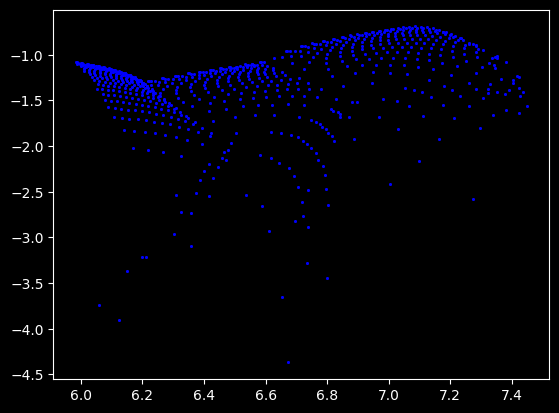

In [ ]:
with np.errstate(invalid='ignore', divide='ignore'):
    G_avg = np.where(N_gv > 0, G_sum / N_gv, np.nan)
    V_avg = np.where(N_gv > 0, V_sum / N_gv, np.nan)
    GV = np.where((N_gv > 0) & (V_avg>0), G_avg / V_avg, np.nan)

#normalised index 
gv_vals = GV[~np.isnan(GV)]
if len(gv_vals) > 5:
    gv_min = float(np.nanpercentile(gv_vals, 5))
    gv_max = float(np.nanpercentile(gv_vals, 95))
    GV_norm = np.clip((GV - gv_min) / (gv_max - gv_min + 1e-20), 0, 1)
    GV_norm = np.where(np.isnan(GV), np.nan, GV_norm)
else:
    GV_norm = np.full_like(GV, np.nan)

#statistics and validation
print(f"\n G/V statistics at solidification front:")
if len(gv_vals)>5:
    print(f" Min: {np.nanmin(GV):.2e} K.s/m2")
    print(f" Median: {float(np.nanmedian(GV)):.2e} K.s/m2")
    print(f" Max: {np.nanmax(GV):.2e} K.s/m2")
    print(f" G_avg: {float(np.nanmean(G_avg[~np.isnan(G_avg)])):.2e} K/m")
    print(f" V_avg: {float(np.nanmean(V_avg[~np.isnan(V_avg)])):.2e} m/s")

    assert float(np.nanmax(V_avg)) <= v_s*5, \
    f"WARNING: V_max={np.nanmax(V_avg):.2f} m/s >> v_scan ={v_s} m/s. " \
    f"Check gradient calculation."
    print(f"\n Validation: V_max vs v_scan [OK]")
else:
    print(" WARNING: too few front cells detected.")
    print(" Check that melt pool formed.")


Block 5 - Visualization

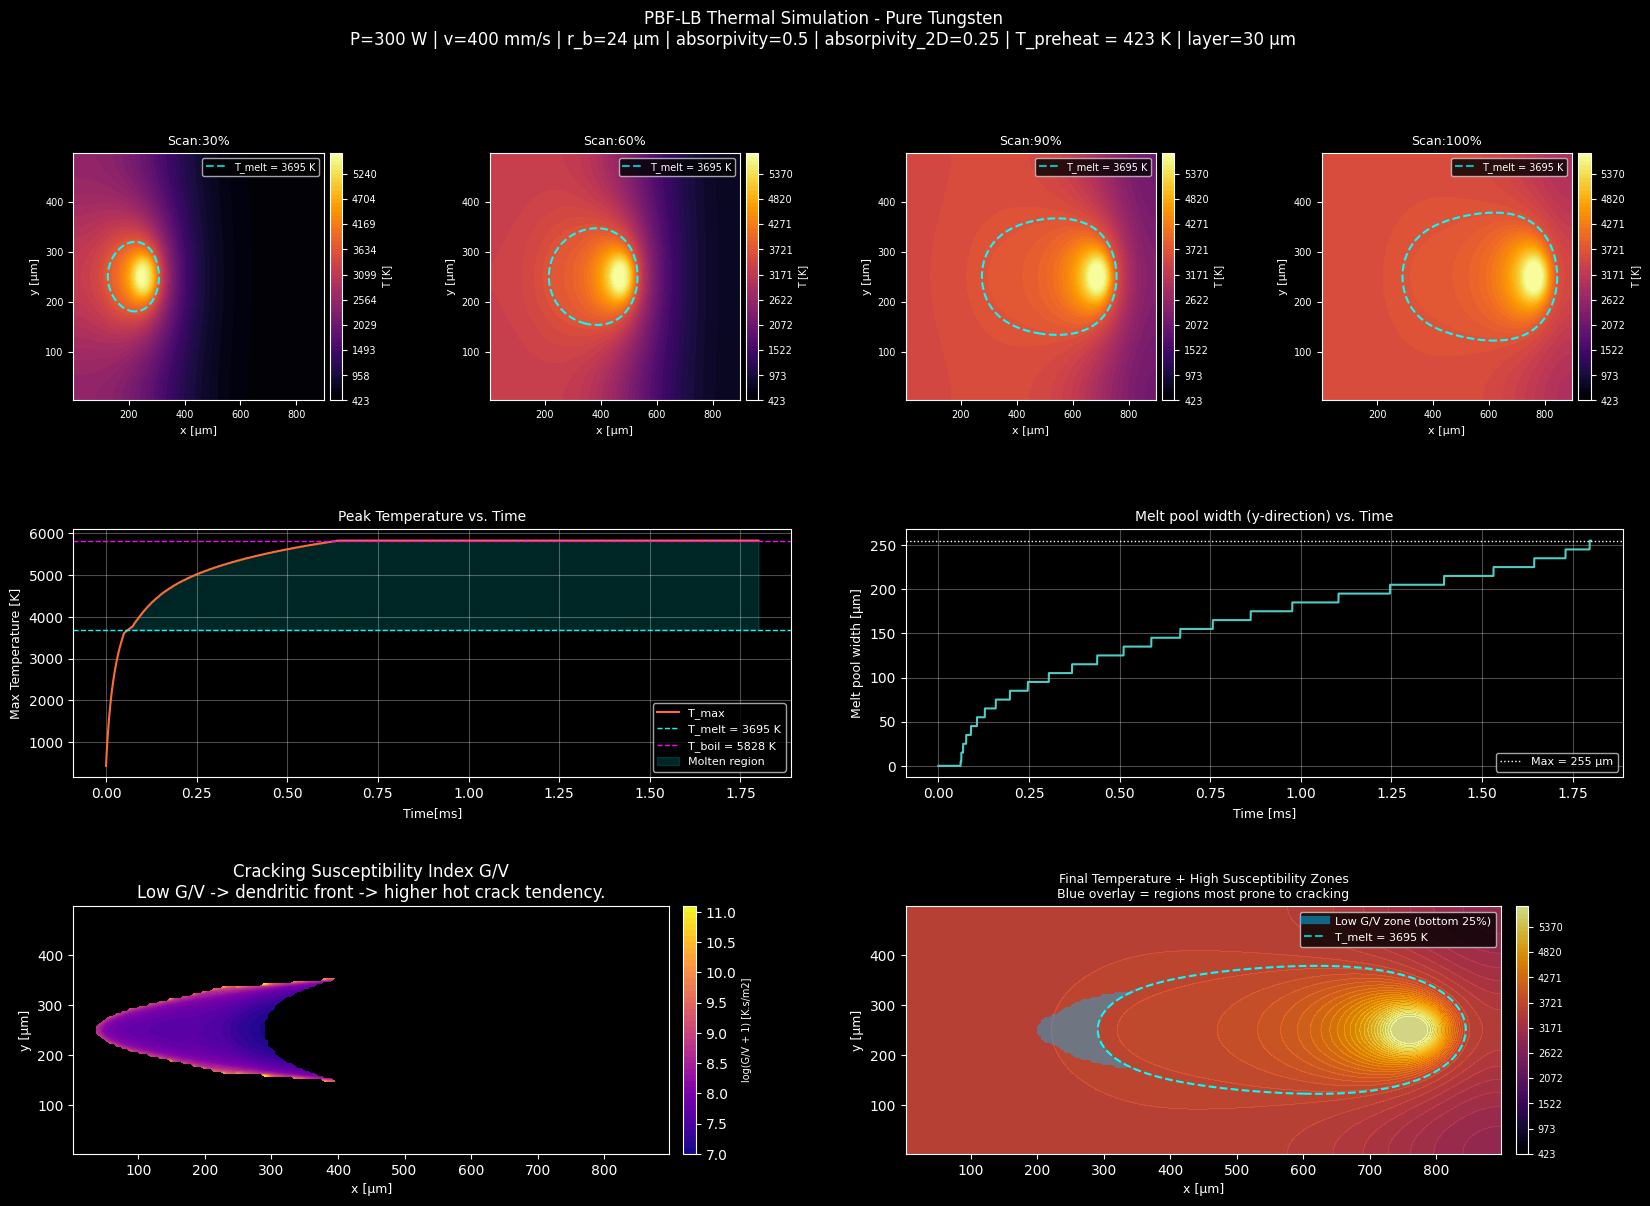

In [264]:
#figure layout
plt.style.use('dark_background')
fig = plt.figure(figsize=(20,13))
fig.suptitle(
    "PBF-LB Thermal Simulation - Pure Tungsten\n"
    f"P={P:.0f} W | v={v_s*1e3:.0f} mm/s | r_b={r_b*1e6:.0f} µm "
    f"| absorpivity={eta} | absorpivity_2D={eta_2D} | T_preheat = {T_init:.0f} K "
    f"| layer={h_lay*1e6:.0f} µm" , fontsize=12, y=0.99
)
gs = GridSpec (3, 4, figure=fig, hspace=0.52, wspace=0.38)

#row 1 - temperature snapshots
snaps = np.stack(snap_T_list, axis=0)
snap_labels = np.array(snap_label_list, dtype=object)
T_max_hist = np.array(T_max_hist)
melt_W_hist = np.array(melt_W_hist)

for col in range (4):
    T_s = snaps[col]
    label = snap_labels[col]
    ax = fig.add_subplot(gs[0, col])
    vmax = float(min(T_s.max(), T_boil))

    im = ax.contourf(X*1e6, Y*1e6, T_s, levels=np.linspace(T_init, vmax, 60), cmap='inferno')
    ax.contour(X*1e6, Y*1e6, T_s, levels=[T_melt], colors='cyan', linewidths=1.5,linestyles='--')
    ax.set_title(f"Scan:{label}", fontsize=9)
    ax.set_xlabel('x [µm]', fontsize=8)
    ax.set_ylabel('y [µm]', fontsize=8)
    ax.tick_params(labelsize=7)
    cb = plt.colorbar(im, ax=ax, pad=0.02)
    cb.set_label('T [K]', fontsize=7)
    cb.ax.tick_params(labelsize=7)
    ax.plot([],[], 'c--', lw=1.5, label=f"T_melt = {T_melt:.0f} K")
    ax.legend(fontsize=7, loc='upper right')

#row 2 - peak temperature vs time
ax2 = fig.add_subplot(gs[1, :2])
t_ms = np.arange(len(T_max_hist)) * dt * 1e3
ax2.plot(t_ms, T_max_hist, color='#FF6B35', lw=1.5, label='T_max')
ax2.axhline(T_melt, color='cyan', ls='--', lw=1, label=f"T_melt = {T_melt:.0f} K")
ax2.axhline(T_boil, color='magenta', ls='--', lw=1, label=f"T_boil = {T_boil:.0f} K")
ax2.fill_between(t_ms, T_melt, T_max_hist, where=np.array(T_max_hist) > T_melt, alpha=0.15, color='cyan', label='Molten region')
ax2.set_xlabel('Time[ms]', fontsize=9)
ax2.set_ylabel('Max Temperature [K]', fontsize=9)
ax2.set_title('Peak Temperature vs. Time', fontsize=10)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

#row 2 - Melt pool width
ax3 = fig.add_subplot(gs[1,2:])
ax3.plot(t_ms, melt_W_hist, color='#4ECDC4', lw=1.5)
ax3.axhline(max(melt_W_hist), color='white', ls=':', lw=1, label=f'Max = {max(melt_W_hist):.0f} µm')
ax3.set_xlabel('Time [ms]', fontsize=9)
ax3.set_ylabel('Melt pool width [µm]', fontsize=9)
ax3.set_title('Melt pool width (y-direction) vs. Time', fontsize=10)
ax3.legend(fontsize=8)
ax3.grid(alpha=0.3)

#row 3 - G/V map
ax4 = fig.add_subplot(gs[2, :2])
has_gv = not np.all(np.isnan(GV))
if has_gv:
    GV_log = np.log10(GV + 1.0)
    im4 = ax4.contourf(X*1e6, Y*1e6, GV_log, levels=40, cmap='plasma')
    cb4 = plt.colorbar(im4, ax=ax4, pad=0.02)
    cb4.set_label('log(G/V + 1) [K.s/m2]', fontsize=7)
    ax4.set_title('Cracking Susceptibility Index G/V\n'
                  'Low G/V -> dendritic front -> higher hot crack tendency.')
else:
    ax4.text(0.5, 0.5, "No G/V data (solidification front not detected)", ha='center', va='center', transform=ax4.transAxes, fontsize=10, color='white')

ax4.set_xlabel('x [µm]', fontsize=9)
ax4.set_ylabel('y [µm]', fontsize=9)

#row 3 - final T + high susceptibility zones
ax5 = fig.add_subplot(gs[2, 2:])
T_f = snaps[-1]
vmax = float(min(T_f.max(), T_boil))
im5 = ax5.contourf(X*1e6, Y*1e6, T_f, levels=np.linspace(T_init, vmax, 60), cmap='inferno', alpha=0.85)

#overlay bottom 25% G/V zones
if has_gv and len(gv_vals) > 10:
    thr = float(np.nanpercentile(gv_vals, 25))
    mask = np.where(GV <=thr, 1.0, 0.0)
    ax5.contourf(X*1e6, Y*1e6, mask, levels=[0.5, 1.5], colors=['deepskyblue'], alpha=0.40)
    ax5.plot([], [], color='deepskyblue', lw=6, alpha=0.5, label='Low G/V zone (bottom 25%)')

ax5.contour(X*1e6, Y*1e6, T_f, levels=[T_melt], colors='cyan', linewidths=1.5, linestyles='--')
ax5.plot([], [], 'c--', lw=1.5, label=f'T_melt = {T_melt:.0f} K')
ax5.set_title('Final Temperature + High Susceptibility Zones\n'
              'Blue overlay = regions most prone to cracking', fontsize=9)
ax5.set_xlabel('x [µm]', fontsize=9)
ax5.set_ylabel('y [µm]', fontsize=9)
ax5.legend(fontsize=8)
plt.colorbar(im5, ax=ax5, pad=0.02).ax.tick_params(labelsize=7)